# Day6: 자연어 모델 이해와 실습

## 학습 내용
1. RNN 의 이해
2. LSTM 의 이해

In [3]:
# 파이토치 관련 라이브러리
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
from urllib import request

import torch
from torch import nn, optim

In [2]:
# warning 표시 끄기
import warnings
warnings.simplefilter('ignore')

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (4,4)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True
plt.rcParams["grid.linestyle"] = ":"

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [3]:
# GPU 디바이스 할당

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


## 1. Vanillla RNN

### RNN 모델 구조

In [ ]:
def torch_seed(seed = 1234):
    # CPU에서 PyTorch의 난수 생성기에 시드를 설정
    torch.manual_seed(seed)
    # CUDA(GPU)에서 PyTorch의 난수 생성기에 시드를 설정
    torch.cuda.manual_seed(seed)

In [ ]:
# 입력 데이터의 피처(feature) 개수 (예: 특성 차원)
input_size = 2
# RNN이나 LSTM 셀이 내부적으로 가질 은닉 상태(Hidden State)의 크기
hidden_size = 4

# (batch_size, time_steps, input_size) 형태의 무작위 텐서를 생성
# batch_size=1, time_steps=5, input_size=2
# torch.rand()는 0과 1 사이의 균일 분포(Uniform distribution)에서 값을 추출
inputs = torch.rand((1, 5, input_size)) # U(0, 1) 
print(inputs)
print(inputs.dtype)

tensor([[[0.6339, 0.1936],
         [0.7457, 0.9306],
         [0.2229, 0.7077],
         [0.6732, 0.3177],
         [0.5647, 0.9681]]])
torch.float32


In [ ]:
# 입력 데이터의 피처(feature) 개수 (예: 특성 차원)
input_size = 2
# RNN 셀이 내부적으로 가질 은닉 상태(Hidden State)의 크기
hidden_size = 4
# input_size=2, hidden_size=4 이며,
# batch_first=True는 입력 텐서의 모양이 (배치 크기(문장 개수), 시퀀스 길이, 피처 수) 순서임을 지정합니다.
rnn = nn.RNN(input_size, hidden_size, batch_first=True)
print('hidden weights = \n')
list(rnn.parameters())

hidden weights = 



[Parameter containing:
 tensor([[ 0.1596,  0.4669],
         [ 0.4534,  0.1711],
         [ 0.0165, -0.3078],
         [-0.2745, -0.3901]], requires_grad=True),
 Parameter containing:
 tensor([[-0.0795,  0.0967,  0.1092, -0.2750],
         [-0.2052,  0.3262,  0.0966,  0.1289],
         [ 0.2672,  0.4172, -0.4803, -0.1332],
         [-0.3961,  0.4866, -0.2729, -0.2721]], requires_grad=True),
 Parameter containing:
 tensor([-0.3847, -0.0426,  0.4173,  0.1761], requires_grad=True),
 Parameter containing:
 tensor([-0.0306, -0.0519,  0.3092, -0.2805], requires_grad=True)]

In [ ]:
outputs, _status = rnn(inputs) # inputs = (1, 5, 2)
print("hiddens = \n", outputs)  ## 모든 노드
print("terminal = \n", _status)  ## 마지막 노드

hiddens = 
 tensor([[[ 0.0431, -0.1188,  0.4410,  0.3075],
         [-0.4413, -0.4776,  0.3049,  0.0399],
         [-0.1816, -0.3200,  0.1367, -0.2988],
         [-0.1320, -0.1427,  0.4995,  0.0345],
         [-0.4053, -0.3780,  0.2290, -0.2015]]], grad_fn=<TransposeBackward1>)
terminal = 
 tensor([[[-0.4053, -0.3780,  0.2290, -0.2015]]], grad_fn=<StackBackward0>)


### 문자단위 RNN

In [ ]:
input_str = 'apple'
label_str = 'pple!'

### Vocab set

In [ ]:
# 1. vocab set
# 입력 문자열(input_str)과 레이블 문자열(label_str)을 합친 후
# set()을 이용해 중복 문자를 제거하고, list()로 변환한 뒤,
# sorted()를 이용해 정렬하여 문자 집합(Vocabulary)을 만듭니다.
char_vocab = sorted(list(set(input_str+label_str)))
# 문자 집합에 포함된 고유 문자의 개수(어휘 크기)를 계산합니다.
vocab_size = len(char_vocab)
# 문자 집합의 크기를 출력합니다.
print ('문자 집합의 크기 : {}'.format(vocab_size))
print(char_vocab)

문자 집합의 크기 : 5
['!', 'a', 'e', 'l', 'p']


### 문자 집합에 고유한 정수를 부여

In [ ]:
# 2. 문자 집합에 고유한 정수를 부여
# char_vocab 리스트의 각 문자에 대해 고유한 정수 인덱스를 부여하여 딕셔너리를 생성합니다.
# '문자' -> '정수 인덱스' 매핑 (예: {'a': 0, 'b': 1, ...})
char_to_index = dict((c, i) for i, c in enumerate(char_vocab)) 
print(char_to_index)

# char_vocab 리스트의 각 인덱스와 문자를 뒤집어 딕셔너리를 생성합니다.
# '정수 인덱스' -> '문자' 매핑 (예: {0: 'a', 1: 'b', ...})
index_to_char = dict((i, c) for i, c in enumerate(char_vocab)) 
print(index_to_char)

{'!': 0, 'a': 1, 'e': 2, 'l': 3, 'p': 4}
{0: '!', 1: 'a', 2: 'e', 3: 'l', 4: 'p'}


### Label encoding 만들기

In [ ]:
# 3. Label encoding

# 입력 문자열(input_str)의 각 문자를 이전에 정의된 딕셔너리
# (char_to_index)를 사용하여 해당 정수 인덱스로 변환합니다.
# 이 리스트는 모델의 입력 데이터(x_data)가 됩니다.
x_data = [char_to_index[c] for c in input_str]

# 레이블 문자열(label_str)의 각 문자를 char_to_index를 사용하여
# 해당 정수 인덱스로 변환합니다.
# 이 리스트는 모델이 예측해야 할 정답 데이터(y_data)가 됩니다.
y_data = [char_to_index[c] for c in label_str]
print(x_data)
print(y_data)


[1, 4, 4, 3, 2]
[4, 4, 3, 2, 0]


In [ ]:
# 배치 차원 추가
x_data = [x_data]
y_data = [y_data]
print(x_data)
print(y_data)

[[1, 4, 4, 3, 2]]
[[4, 4, 3, 2, 0]]


### Onehot encoding

In [ ]:
# 4. Onehot encoding

# numpy의 np.eye 함수를 사용하여 x_data(정수 인덱스 리스트)를
# 원-핫 벡터(one-hot vector) 형태로 변환합니다.
# x_one_hot의 최종 형태는 (시퀀스 길이, 어휘 크기)가 됩니다.
x_one_hot = np.eye(vocab_size)[x_data]
print(x_one_hot)

[[[0. 1. 0. 0. 0.]
  [0. 0. 0. 0. 1.]
  [0. 0. 0. 0. 1.]
  [0. 0. 0. 1. 0.]
  [0. 0. 1. 0. 0.]]]


### Tensor input 만들기

In [ ]:
# numpy 배열인 x_one_hot을 PyTorch의 FloatTensor (32비트 부동소수점) 타입으로 변환합니다.
X = torch.FloatTensor(x_one_hot) # torch.tensor(x_one_hot).float() 
# y_data(정수 인덱스 리스트)를 PyTorch의 LongTensor (64비트 정수) 타입으로 변환합니다.
Y = torch.LongTensor(y_data)
print('훈련 데이터의 크기 : {}'.format(X.shape))
print('레이블의 크기 : {}'.format(Y.shape))
print("X = \n", X)
print("Y = \n", Y)
# X는 One-hot Encoding 되어야한다.

훈련 데이터의 크기 : torch.Size([1, 5, 5])
레이블의 크기 : torch.Size([1, 5])
X = 
 tensor([[[0., 1., 0., 0., 0.],
         [0., 0., 0., 0., 1.],
         [0., 0., 0., 0., 1.],
         [0., 0., 0., 1., 0.],
         [0., 0., 1., 0., 0.]]])
Y = 
 tensor([[4, 4, 3, 2, 0]])


### RNN 모델 만들기

In [ ]:
# RNN 셀의 입력 크기(차원). 원-핫 인코딩된 벡터의 차원과 같습니다.
input_size = vocab_size # 입력의 크기는 문자 집합의 크기
hidden_size = 6 # RNN 셀이 내부적으로 가질 은닉 상태(Hidden State)의 크기.

# 실제 프로젝트에서는 Onehot Encoding 수행 후 단어 임베딩도 수행해야한다.
# 지금은 실습 상 단어 임베딩 과정을 생략한다.

# 최종 출력층의 크기(차원). 이 예시에서는 예측해야 할 클래스(문자)의 개수입니다.
# 참고: 이 output_size는 실제로는 vocab_size와 같아야 합니다.
output_size = 5 

# 옵티마이저(Optimizer)가 손실(Loss)을 줄이기 위해
# 모델의 가중치를 얼마나 크게 업데이트할지 결정하는 비율입니다.
learning_rate = 0.1

In [ ]:
 # PyTorch의 nn.Module을 상속받아 기본적인 순환 신경망(RNN) 모델을 정의하는 클래스입니다.
class VanillaRNN(nn.Module):
   # input_size: 입력 벡터의 크기 (vocab_size)
    # hidden_size: 은닉 상태 벡터의 크기
    # batch_first=True: 입력 텐서 순서를 (batch_size, sequence_length, feature_size)로 설정
    def __init__(self, input_size, hidden_size, output_size):
        super(VanillaRNN, self).__init__()        
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True) # RNN 셀 구현
        # RNN의 최종 은닉 상태를 받아 output_size 크기로 변환합니다.
        # hidden_size: 입력 크기 (RNN 출력의 크기)
        # output_size: 출력 크기 (예측해야 할 클래스/문자의 개수)
        self.fc = nn.Linear(hidden_size, output_size, bias=True) # 출력층 구현

    # 모델의 순전파(forward propagation)를 정의하는 함수입니다. 
    def forward(self, x): # 구현한 RNN 셀과 출력층을 연결
        x, _status = self.rnn(x)
        x = self.fc(x) # ^y 값과 동일
        return x

In [ ]:
# 위에서 정의된 VanillaRNN 클래스의 인스턴스(객체)를 생성합니다.
net = VanillaRNN(input_size, hidden_size, output_size)

### Output 크기

In [ ]:
# 모델(net)에 입력 데이터(X)를 넣어 순전파(forward propagation)를 수행합니다.
# 이로써 각 시점(time step)마다 다음 문자에 대한 예측 결과(로짓)를 얻습니다.
# X의 형태: (batch_size=1, sequence_length=5, input_size=5)라고 가정합니다.
outputs = net(X) # X.shape = torch.Size([1, 5, 5])

print(outputs.shape) # 3차원 텐서
print(outputs)

torch.Size([1, 5, 5])
tensor([[[-0.0652,  0.1190, -0.0009,  0.0478, -0.1830],
         [ 0.0547, -0.0922,  0.2363, -0.0959, -0.6068],
         [-0.1130, -0.2413,  0.3055, -0.0376, -0.6839],
         [-0.2527,  0.1747,  0.0734, -0.2654, -0.2116],
         [-0.2246,  0.0805,  0.0633, -0.2838, -0.3930]]],
       grad_fn=<ViewBackward0>)


In [ ]:
# 모델의 3차원 출력 텐서(outputs)를 2차원 텐서로 변형합니다.
# -1은 PyTorch에게 첫 번째 차원의 크기를 자동으로 계산하도록 지시하며,
# input_size는 두 번째 차원의 크기(vocab_size 또는 output_size)가 됩니다.
print(outputs.view(-1, input_size)) # 2차원 텐서로 변환
print(Y.view(-1))

tensor([[-0.0652,  0.1190, -0.0009,  0.0478, -0.1830],
        [ 0.0547, -0.0922,  0.2363, -0.0959, -0.6068],
        [-0.1130, -0.2413,  0.3055, -0.0376, -0.6839],
        [-0.2527,  0.1747,  0.0734, -0.2654, -0.2116],
        [-0.2246,  0.0805,  0.0633, -0.2838, -0.3930]],
       grad_fn=<ViewBackward0>)
tensor([4, 4, 3, 2, 0])


### Loss function, optimizer 정의

In [ ]:
# 분류 문제에서 자주 사용되는 교차 엔트로피 손실 함수를 정의합니다.
# 이 함수는 모델의 예측(로짓)과 정답 레이블(정수 인덱스) 간의 차이를 계산합니다.
criterion = nn.CrossEntropyLoss()
# 모델의 가중치(parameters)를 업데이트하여 손실을 최소화하는 데 사용되는 알고리즘(Adam)을 정의합니다.
# net.parameters(): 학습할 모델의 모든 가중치와 편향을 가져옵니다.
# learning_rate: 한 번 업데이트할 때 가중치를 얼마나 변경할지 지정합니다.
optimizer = optim.Adam(net.parameters(), learning_rate)

### RNN 모델 학습

In [ ]:
# output shape = (1, 5, 5)
# Y shape = (1, 5)

for i in range(100):

    outputs = net(X)
    loss = criterion(outputs.view(-1, output_size), Y.view(-1)) # view를 하는 이유는 Batch 차원 제거를 위해, CrossEntropyLoss: outputs should be (N, C), and Y should be (N, )

    optimizer.zero_grad() # 초기화
    loss.backward() # 기울기 계산
    optimizer.step() # 아까 optimizer 선언 시 넣어둔 파라미터 업데이트

    # 아래 세 줄은 모델이 실제 어떻게 예측했는지를 확인하기 위한 코드.
    result = outputs.argmax(axis=2) # 최종 예측값인 각 time-step 별 5차원 벡터에 대해서 가장 높은 값의 인덱스를 선택
    result_str = ''.join([index_to_char[c] for c in np.squeeze(result.numpy())]) # np.squeeze(result.numpy()) : 1d vector
    print(i, "loss: ", round(loss.item(), 3), "prediction: ", result, "true Y: ", y_data, "prediction str: ", result_str)

0 loss:  1.727 prediction:  tensor([[1, 2, 2, 1, 1]]) true Y:  [[4, 4, 3, 2, 0]] prediction str:  aeeaa
1 loss:  1.451 prediction:  tensor([[3, 3, 3, 2, 3]]) true Y:  [[4, 4, 3, 2, 0]] prediction str:  lllel
2 loss:  1.19 prediction:  tensor([[4, 4, 3, 2, 0]]) true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
3 loss:  0.912 prediction:  tensor([[4, 4, 3, 2, 0]]) true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
4 loss:  0.654 prediction:  tensor([[4, 4, 3, 2, 0]]) true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
5 loss:  0.454 prediction:  tensor([[4, 4, 3, 2, 0]]) true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
6 loss:  0.31 prediction:  tensor([[4, 4, 3, 2, 0]]) true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
7 loss:  0.194 prediction:  tensor([[4, 4, 3, 2, 0]]) true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
8 loss:  0.111 prediction:  tensor([[4, 4, 3, 2, 0]]) true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
9 loss:  0.062 prediction:  tensor([[4, 4, 3, 2, 0]]) true Y:  [[4

### 한글을 이용한 RNN

In [ ]:
# text = "공복에 드셔야 흡수가 잘되기 때문입니다. 공복에 드셨을 때 소화가 잘 되지 않는 분들은 식후에 드시는 것이 좋아요. 생들기름은 성인 기준으로 하루 5g정도 드시면 충분합니다. 숟가락에 따랐을 때 반절이면 5g이에요."
text = "안녕하세요 여러분"
input_str_kr = text
label_str_kr = text[1:] + "!"

print(input_str_kr)
print(label_str_kr)

# input_str_kr = '안녕하세요 여러분'
# label_str_kr = '녕하세요 여러분!'


안녕하세요 여러분
녕하세요 여러분!


In [ ]:

## 1. Vocabulary set
voc_set = set(input_str_kr+label_str_kr)
char_vocab = sorted(list(voc_set))
vocab_size = len(char_vocab)
print ('문자 집합의 크기 : {}'.format(vocab_size))
print("Vocabulary set = ", voc_set)
print("="*50)


문자 집합의 크기 : 10
Vocabulary set =  {'요', '러', '분', '녕', '여', '세', ' ', '!', '하', '안'}


In [ ]:

# 2. 문자 집합에 고유한 정수를 부여
char_to_index = dict((c, i) for i, c in enumerate(char_vocab)) # 문자에 고유한 정수 인덱스 부여
print("Char to index = \n", char_to_index)

index_to_char = dict((i, c) for i, c in enumerate(char_vocab)) # 문자에 고유한 정수 인덱스 부여
print("Idx to char = \n",index_to_char)
print("="*50)


Char to index = 
 {' ': 0, '!': 1, '녕': 2, '러': 3, '분': 4, '세': 5, '안': 6, '여': 7, '요': 8, '하': 9}
Idx to char = 
 {0: ' ', 1: '!', 2: '녕', 3: '러', 4: '분', 5: '세', 6: '안', 7: '여', 8: '요', 9: '하'}


In [ ]:
# 3. Label encoding
x_data = [char_to_index[c] for c in input_str_kr]
y_data = [char_to_index[c] for c in label_str_kr]

# 배치 차원 추가
x_data = [x_data]
y_data = [y_data]

print("Label encoding = \n")
print("input_str = \n", x_data)
print("output_str = \n",y_data)
print("="*50)


Label encoding = 

input_str = 
 [[6, 2, 9, 5, 8, 0, 7, 3, 4]]
output_str = 
 [[2, 9, 5, 8, 0, 7, 3, 4, 1]]


In [ ]:

# 4. Onehot encoding
# X만 Onehot encoding 수행
print('input_str One hot encoding =')
# x_one_hot = [np.eye(vocab_size)[x] for x in x_data]
x_one_hot = np.eye(vocab_size)[x_data] # Identity Matrix
print(x_one_hot) 
print(x_one_hot.shape()) # (배치차원(문장 수), 타입스텝, 임베딩 차원) 형태로 결과 출력


input_str One hot encoding =
[[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
  [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
  [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]]


In [ ]:

# 5. Tensor vector
X = torch.FloatTensor(x_one_hot) # float32
Y = torch.LongTensor(y_data) # int64
print('훈련 데이터의 크기 : {}'.format(X.shape))
print('레이블의 크기 : {}'.format(Y.shape))
print(X)
print(Y)

훈련 데이터의 크기 : torch.Size([1, 9, 10])
레이블의 크기 : torch.Size([1, 9])
tensor([[[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
         [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
         [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]]])
tensor([[2, 9, 5, 8, 0, 7, 3, 4, 1]])


In [ ]:
# 5. Model
vocab_size = len(char_vocab)
input_size = vocab_size # 입력의 크기는 문자 집합의 크기
hidden_size = 5 # 은닉층은 5개
output_size = vocab_size 
learning_rate = 0.1

class VanillaRNN_Kor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(VanillaRNN_Kor, self).__init__()
        self.rnn = torch.nn.RNN(input_size, hidden_size, batch_first=True) # RNN 셀 구현
        self.fc = torch.nn.Linear(hidden_size, output_size, bias=True) # 출력층 구현 # bias 는 생략해도 기본값은 True

    def forward(self, x): # 구현한 RNN 셀과 출력층을 연결
        x, _status = self.rnn(x) # 실습에서는 쓰지 않지만 _status 는 seq2seq의 context 노드 값 의미
        x = self.fc(x)
        return x

net = VanillaRNN_Kor(input_size, hidden_size, output_size)
print("RNN parameters = \n", net.parameters)
# list(net.parameters())

outputs = net(X)
print(outputs.shape) # 3차원 텐서 # ouputs.shape 하면 브로드캐스팅 과정에서 디멘션 에러 발생 가능. 그래서 차원하나 제거
# print(outputs)
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), learning_rate)

for i in range(100):

    outputs = net(X)
    loss = criterion(outputs.view(-1, input_size), Y.view(-1)) # view를 하는 이유는 Batch 차원 제거를 위해 # 브로드캐스팅 과정에서 디멘션 에러 발생 가능. 그래서 차원하나 제거(squeeze 함수 사용도 가능)
    # torch.Size([9, 10])
    # loss = criterion(outputs, Y) # view를 하는 이유는 Batch 차원 제거를 위해, doesnot work

    # 학습 수행 (오류 역전파 사용)
    optimizer.zero_grad() # 반드시 초기화 수행
    loss.backward() # 기울기 계산
    optimizer.step() # 아까 optimizer 선언 시 넣어둔 파라미터 업데이트

    # 아래 세 줄은 모델이 실제 어떻게 예측했는지를 확인하기 위한 코드.
    result = outputs.argmax(axis=2) # 최종 예측값인 각 time-step 별 5차원 벡터에 대해서 가장 높은 값의 인덱스를 선택
    result_str = ''.join([index_to_char[c] for c in np.squeeze(result.numpy())]) # np.squeeze(result.numpy()) : 1d vector
    print(i, "loss: ", loss.item(), "prediction: ", result, "true Y: ", y_data, "prediction str: ", result_str)

RNN parameters = 
 <bound method Module.parameters of VanillaRNN_Kor(
  (rnn): RNN(10, 20, batch_first=True)
  (fc): Linear(in_features=20, out_features=10, bias=True)
)>
torch.Size([1, 9, 10])
0 loss:  2.2905445098876953 prediction:  tensor([[8, 1, 1, 1, 8, 7, 8, 8, 8]]) true Y:  [[2, 9, 5, 8, 0, 7, 3, 4, 1]] prediction str:  요!!!요여요요요
1 loss:  1.9417288303375244 prediction:  tensor([[3, 9, 7, 7, 0, 7, 7, 7, 7]]) true Y:  [[2, 9, 5, 8, 0, 7, 3, 4, 1]] prediction str:  러하여여 여여여여
2 loss:  1.3427523374557495 prediction:  tensor([[2, 9, 5, 8, 0, 7, 3, 9, 1]]) true Y:  [[2, 9, 5, 8, 0, 7, 3, 4, 1]] prediction str:  녕하세요 여러하!
3 loss:  0.6551940441131592 prediction:  tensor([[2, 9, 5, 8, 0, 7, 3, 4, 1]]) true Y:  [[2, 9, 5, 8, 0, 7, 3, 4, 1]] prediction str:  녕하세요 여러분!
4 loss:  0.22501195967197418 prediction:  tensor([[2, 9, 5, 8, 0, 7, 3, 4, 1]]) true Y:  [[2, 9, 5, 8, 0, 7, 3, 4, 1]] prediction str:  녕하세요 여러분!
5 loss:  0.07384788990020752 prediction:  tensor([[2, 9, 5, 8, 0, 7, 3, 4, 1]]) 

## 2. LSTM을 이용한 네이버 영화 리뷰 분류

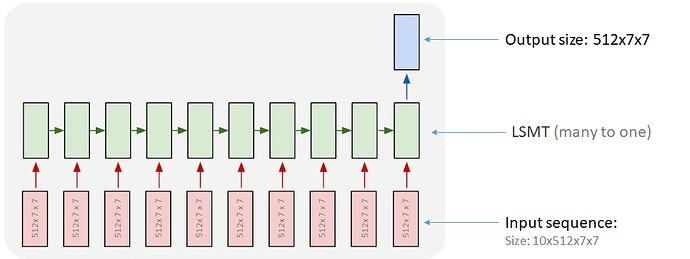

In [ ]:
# Image("../fig/many_to_one_lstm.jpg")

### LSTM 모델 확인하기

In [ ]:
## parameter
input_dim = 5
hidden_size = 3

# (batch_size, time_steps, input_size)
inputs = torch.rand(1, 3, 5)
print(inputs)
print(inputs.dtype)

tensor([[[0.7672, 0.2364, 0.5970, 0.2760, 0.5460],
         [0.7098, 0.3053, 0.2820, 0.8642, 0.7860],
         [0.6414, 0.5971, 0.5416, 0.8085, 0.6678]]])
torch.float32


In [ ]:
# 입력 데이터의 피처(feature) 개수 (예: 원-핫 벡터의 크기, vocab_size)
input_dim = 5
# LSTM 셀이 내부적으로 가질 은닉 상태(Hidden State)와 셀 상태(Cell State)의 크기
hidden_size = 3

# input_dim=5, hidden_size=3 이며,
# batch_first=True는 입력 텐서의 모양이 (배치 크기, 시퀀스 길이, 피처 수) 순서임을 지정합니다.
lstm = nn.LSTM(input_dim, hidden_size, batch_first=True)

In [ ]:
# input_dim: 입력 피처 크기, hidden_size: 은닉 상태 크기, batch_first=True 설정
lstm = nn.LSTM(input_dim, hidden_size, batch_first=True)

# lstm.parameters()를 호출하여 학습 가능한 모든 가중치와 편향을 가져온 후,
# list()로 변환하여 출력합니다.
# LSTM은 입력-은닉 가중치, 은닉-은닉 가중치, 두 종류의 편향을 포함합니다.
print(list(lstm.parameters()))

[Parameter containing:
tensor([[ 0.1166, -0.0219,  0.1621,  0.1093,  0.0347],
        [ 0.3434,  0.3256,  0.3027, -0.0485,  0.1695],
        [ 0.5690, -0.0140, -0.2155,  0.4951, -0.3952],
        [-0.2003,  0.2864, -0.2715,  0.0640,  0.4747],
        [ 0.1261, -0.4243, -0.3693,  0.5753, -0.0139],
        [ 0.5120,  0.0815,  0.2055, -0.4846,  0.3030],
        [ 0.5661,  0.2632,  0.0814,  0.1802,  0.4378],
        [ 0.5485,  0.0081, -0.5053,  0.3858, -0.0966],
        [-0.1218, -0.2254,  0.2792, -0.2061, -0.0436],
        [-0.2515, -0.5677,  0.5511,  0.5500,  0.1851],
        [-0.5522,  0.3118, -0.5050,  0.0744,  0.2483],
        [ 0.1167, -0.0363, -0.3061, -0.4505, -0.0243]], requires_grad=True), Parameter containing:
tensor([[-0.1608, -0.2422, -0.3848],
        [ 0.4449, -0.4194,  0.2323],
        [-0.3251,  0.2709, -0.2746],
        [-0.2488,  0.0455, -0.4512],
        [-0.0907, -0.0411, -0.3842],
        [-0.2733, -0.2857,  0.3349],
        [-0.0947,  0.3412, -0.4912],
        [ 0.32

### 데이터 다운 로드

In [ ]:
# 데이터 로드하기
# 현재 작업 디렉토리에 'ratings_train.txt'라는 이름으로 저장합니다. (학습용 데이터)
request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
                    filename="ratings_train.txt")
# 현재 작업 디렉토리에 'ratings_test.txt'라는 이름으로 저장합니다. (평가용 데이터)
request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt",
                    filename="ratings_test.txt")

('ratings_test.txt', <http.client.HTTPMessage at 0x7ff6eddd8440>)

In [ ]:
# ratings_train.txt 파일을 탭('\t')을 구분자로 사용하여 판다스 데이터프레임으로 불러옵니다.
# nrows=100을 설정하여 파일의 처음 100개 행(샘플)만 읽어옵니다.
train_data = pd.read_table('ratings_train.txt', sep = "\t", nrows = 100)

# ratings_test.txt 파일을 탭('\t')을 구분자로 사용하여 판다스 데이터프레임으로 불러옵니다.
# 마찬가지로 nrows=100을 설정하여 처음 100개 행만 읽어옵니다.
test_data = pd.read_table('ratings_test.txt', sep = "\t", nrows = 100)
print('총 샘플의 수 :',len(train_data))
train_data.head()

총 샘플의 수 : 100


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


### 데이터 전처리

In [ ]:
# inplace=True: 변경 사항을 train_data에 바로 적용합니다.
# how="any": 행의 값 중 하나라도 결측값(NaN)이 있으면 해당 행을 제거합니다.
train_data.dropna(inplace=True, how = "any")

# subset=['document']: 'document' 열을 기준으로 중복되는 행이 있는지 검사합니다.
# inplace=True: 변경 사항을 train_data에 바로 적용하며, 중복되는 행 중 첫 번째만 남기고 나머지를 제거합니다.
train_data.drop_duplicates(subset=['document'], inplace=True)

print('총 샘플의 수 :',len(train_data))
train_data.head()

총 샘플의 수 : 100


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [ ]:
### 한글과 공백을 제외하고 모두 제거
# '[^ㄱ-ㅎㅏ-ㅣ가-힣 ]': 정규 표현식(regex) 패턴입니다.
# - '^'는 '부정(not)'을 의미하며, 대괄호 안에 있는 문자(한글 자음, 모음, 완성형 글자, 공백)를 제외한 모든 문자를 뜻합니다.
# " ": 제외된 모든 문자를 공백(' ')으로 치환합니다.
# regex=True: 정규 표현식 엔진을 사용하도록 지정합니다.
train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]"," ",
                                                             regex=True)
train_data.head(20)

,id,document,label
0,9976970,아 더빙 진짜 짜증나네요 목소리,0
1,3819312,흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 솔직히 재미는 없다 평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [ ]:
### 빈자료 제거

# 'document' 열의 문자열 양 끝에 있는 공백(whitespace)을 제거합니다.
train_data['document'] = train_data['document'].str.strip()

# 앞 단계에서 양 끝 공백을 제거한 결과로 남은 빈 문자열('')을
# numpy의 결측값(np.nan)으로 치환합니다.
train_data['document'] = train_data['document'].replace('', np.nan)

# 'document' 열에 새로 생긴 결측값을 포함하여, NaN이 있는 모든 행을 제거합니다.
# how='any'는 해당 행에 하나라도 NaN이 있으면 제거함을 의미합니다.
train_data.dropna(how = 'any', inplace=True)

# 각 열별 결측값(NaN)의 개수를 다시 한 번 출력하여 제거가 완료되었는지 확인합니다.
print(train_data.isnull().sum())
print(train_data.shape) # (145393, 3)

id          0
document    0
label       0
dtype: int64
(100, 3)


### 토큰화 (Tokenizing)

In [ ]:
# 한국어 자연어 처리(NLP)를 위한 라이브러리인 'konlpy'를 설치합니다.
# 이 라이브러리는 형태소 분석, 태깅 등을 수행하는 데 필요합니다.

# !pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 42.3 MB/s eta 0:00:00


In [ ]:
# Okt는 한국어 텍스트를 형태소 단위로 분석하고 품사를 태깅하는 데 사용됩니다.
from konlpy.tag import Okt
# 딥러닝이나 데이터 처리 과정에서 시간이 오래 걸리는 작업의 진행률을 확인하는 데 유용합니다.
from tqdm import tqdm

In [ ]:
# 불용어(Stopwords) 정의:
# 한국어에서 자주 등장하지만 문장의 의미를 분석하는 데 크게 기여하지 않는 단어들(조사, 어미 등)을 리스트로 정의합니다.
stopwords = ['아', '도', '는', '다', '의', '가', '이', '은', '한', '에', '하', '고', '을', '를', '인', '듯', '과', '와', '네', '들', '듯', '지', '임', '게']
# Okt 형태소 분석기 객체 생성:
# Konlpy 라이브러리의 Okt(Open Korean Text) 분석기를 초기화합니다.
okt = Okt()
# 형태소 분석(Morphs) 실행:
# 주어진 한글 문장을 입력으로 받아 형태소 단위로 분리하고, 분리된 형태소 리스트를 반환합니다.
# 예시 출력: ['교도소', '이야기', '구먼', '솔직히', '재미', '는', '없다', '평점', '조정']
okt.morphs("교도소 이야기구먼 솔직히 재미는 없다평점 조정")

['교도소', '이야기', '구먼', '솔직히', '재미', '는', '없다', '평점', '조정']

In [ ]:
X_data = []

# tqdm을 사용하여 train_data의 'document' 열에 있는 모든 문장(리뷰)을 순회하며 진행 상황을 표시합니다.
for sentence in tqdm(train_data['document']): # for sentence in train_data['document']: 
    # 형태소 분석 및 어간 추출(Stemming)을 수행합니다.
    # okt.morphs(): 문장을 형태소 단위로 분리합니다.
    # stem=True: 각 형태소의 어간(기본형)을 추출하여 '재미있다' -> '재미있다' 대신 '재미있'처럼 만듭니다.   
    tokenized_sentence = okt.morphs(sentence, stem=True) # 토큰화
    # 불용어 제거:
    # 토큰화된 문장(tokenized_sentence)에서 미리 정의된 불용어(stopwords) 리스트에 포함되지 않은 단어만 남깁니다.
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords] # 불용어 제거
    # 전처리(토큰화 및 불용어 제거)가 완료된 문장(단어 리스트)을 X_data에 추가합니다.
    X_data.append(stopwords_removed_sentence)

100%|██████████| 100/100 [00:00<00:00, 207.23it/s]


In [ ]:
# 레이블(정답) 데이터 추출:
# train_data 데이터프레임의 'label' 열을 추출하여 모델의 정답 데이터(y_data)로 사용합니다.
# 이 레이블은 0(부정) 또는 1(긍정) 값을 가집니다.
y_data = train_data['label']

print(len(X_data))
print(len(y_data))

print(X_data[:5])
print(y_data[:5])

100
100
[['아', '더빙', '진짜', '짜증나다', '목소리'], ['흠', '포스터', '보고', '초딩', '영화', '줄', '오버', '연기', '조차', '가볍다', '않다'], ['너', '무재', '밓었', '다그', '래서', '보다', '추천'], ['교도소', '이야기', '구먼', '솔직하다', '재미', '없다', '평점', '조정'], ['사이', '몬페', '그', '익살스럽다', '연기', '돋보이다', '영화', '스파이더맨', '에서', '늙다', '보이다', '하다', '커스틴', '던스트', '너무나도', '이쁘다', '보이다']]
0    0
1    1
2    0
3    0
4    1
Name: label, dtype: int64


### 학습데이터, 검증데이터

In [ ]:
from sklearn.model_selection import train_test_split
# 데이터 분할:
# 전체 데이터(X_data, y_data)를 학습 데이터셋과 검증 데이터셋으로 나눕니다.
# test_size=0.2: 전체 데이터 중 20%를 검증 데이터(X_valid, y_valid)로 할당합니다.
# random_state=0: 분할을 고정하여 코드를 다시 실행해도 동일한 결과를 얻도록 재현성을 확보합니다.
# stratify=y_data: 원본 데이터의 레이블(y_data) 비율을 유지하며 분할합니다 (클래스 불균형 방지).
X_train, X_valid, y_train, y_valid = train_test_split(X_data, y_data, test_size=0.2,
                                                      random_state=0, stratify=y_data)
print("X_train shape = ", len(X_train))
print("X_valid shape = ", len(X_valid))
print("y_train shape = ", len(y_train))
print("y_valid shape = ", len(y_valid))


X_train shape =  80
X_valid shape =  20
y_train shape =  80
y_valid shape =  20


### 단어 집합 만들기

In [ ]:
from collections import Counter

word_list = []
# 학습 데이터셋(X_train)의 모든 문장(sent)을 순회합니다.
for sent in X_train:
    # 문장 내의 모든 단어(word)를 순회합니다.
    for word in sent:
      # 각 단어를 word_list에 추가합니다.
      word_list.append(word)

# Counter 객체를 사용하여 word_list에 있는 모든 단어의 출현 빈도를 계산합니다.
# 이 객체의 크기는 고유한 단어의 개수(어휘 크기)와 같습니다.
word_counts = Counter(word_list) # == len(set(word_list))

# 고유한 단어의 총 개수(Vocabulary Size)를 출력합니다.
print('총 단어수 :', len(word_counts))

# 각 단어와 그 빈도수를 저장하고 있는 Counter 객체를 출력합니다.
display(word_counts)


총 단어수 : 529


Counter({'진정': 1,
         '위대하다': 1,
         '영화': 16,
         '최고': 4,
         '설정': 1,
         '재밌다': 7,
         '새롭다': 1,
         '에피소드': 2,
         '내': 5,
         '에서': 4,
         '메인': 1,
         '스토리': 2,
         '차차': 1,
         '나오다': 6,
         '평점': 5,
         '속지': 1,
         '말다': 1,
         '시간': 3,
         '낭비': 2,
         '돈': 2,
         '짤랐을꺼': 1,
         '야': 2,
         '그래서': 3,
         '납득': 1,
         '하다': 20,
         '수': 1,
         '없다': 10,
         '그렇다': 3,
         '꼭': 1,
         '끄다': 3,
         '걍': 1,
         '인피니트': 1,
         '짱': 2,
         '이다': 14,
         '진짜': 4,
         '보다': 15,
         '웃다': 1,
         '않다': 2,
         '건': 2,
         '불가능하다': 1,
         '김남길': 1,
         '백': 2,
         '점': 6,
         '짜다': 1,
         '연기력': 1,
         '초반': 1,
         '몰입도': 1,
         '에도': 1,
         '불구': 1,
         '하고': 2,
         '지루하다': 2,
         '손예진': 1,
         'ㅈㅈ': 1,
         '내일': 1,
         '

In [18]:
print('훈련 데이터에서의 단어 영화의 등장 횟수 :', word_counts['영화']) # class Counter (= dictionary)
print('훈련 데이터에서의 단어 공감의 등장 횟수 :', word_counts['공감'])

훈련 데이터에서의 단어 영화의 등장 횟수 : 16
훈련 데이터에서의 단어 공감의 등장 횟수 : 0


In [ ]:
# word_counts(단어별 빈도수 딕셔너리)를 기반으로 어휘 목록(vocab)을 만듭니다.
# key=word_counts.get: 딕셔너리의 '값'(단어의 빈도수)을 기준으로 정렬합니다.
# reverse=True: 빈도수가 높은 단어부터 낮은 단어 순으로 내림차순 정렬합니다.
vocab = sorted(word_counts, key=word_counts.get, reverse=True) # 정렬 따로하지 않아도 기본적으로 정렬은 수행된 상태
vocab

['하다',
 '영화',
 '보다',
 '이다',
 '없다',
 '재밌다',
 '나오다',
 '점',
 '있다',
 '정말',
 '내',
 '평점',
 '만',
 '드라마',
 '완전',
 '연기',
 '최고',
 '에서',
 '진짜',
 '되다',
 '감동',
 '좋다',
 '왜',
 '보이다',
 '내용',
 '속',
 '시간',
 '그래서',
 '그렇다',
 '끄다',
 '멋지다',
 '싶다',
 '기',
 '전개',
 '또',
 '아',
 '재미',
 '평범하다',
 '그',
 '별',
 'ㅇ',
 '아깝다',
 '재미있다',
 '갈등',
 '자다',
 '아햏햏',
 '사람',
 '것',
 '안',
 '에피소드',
 '스토리',
 '낭비',
 '돈',
 '야',
 '짱',
 '않다',
 '건',
 '백',
 '하고',
 '지루하다',
 '돼다',
 '조금',
 'ㅠㅠ',
 '주다',
 '고추',
 '으로',
 '나가다',
 'ㅜㅜ',
 '언제',
 '끝나다',
 '빨리',
 '어거지',
 '적',
 '중반',
 '캐스팅',
 '년대',
 '향수',
 '쓰레기',
 '이쁘다',
 '몇',
 '죄인',
 '만들다',
 '아니다',
 '이라',
 '라고',
 '근데',
 '이렇게',
 '자체',
 '웃기다',
 '움',
 '이건',
 '뭐',
 '냐',
 '원작',
 '흥행',
 '저',
 '모르다',
 '데',
 '너',
 '에선',
 '제일',
 '감독',
 '님',
 '말',
 '깨알',
 '관객',
 '진창',
 '너무',
 '낮다',
 '못',
 '로',
 '반복',
 '차',
 '조작',
 '안이',
 '열리다',
 '그냥',
 '이기',
 '면',
 '진정',
 '위대하다',
 '설정',
 '새롭다',
 '메인',
 '차차',
 '속지',
 '말다',
 '짤랐을꺼',
 '납득',
 '수',
 '꼭',
 '걍',
 '인피니트',
 '웃다',
 '불가능하다',
 '김남길',
 '짜다',
 '연기력',
 '초반',
 '몰입도',
 '에도',
 '불구'

In [ ]:
# 단어(word)를 고유한 정수 인덱스(index)로 매핑하기 위한 딕셔너리를 초기화합니다.
word_to_index = {}

# 특수 토큰인 <PAD> (Padding)에 가장 작은 인덱스 0을 할당합니다.
# <PAD>는 시퀀스 길이를 맞출 때 사용됩니다. 즉, 긴쪽을 기준으로 길이만 맞추기위한 용도.
# seq2seq 은 <SOS>로 시작하고, <EOS> 로 끝낸다.
word_to_index['<PAD>'] = 0 # [0, 0, 0] <PAD> <PAD> <PAD> => [0, 0, 0, 0, 0, 0]

# 특수 토큰인 <UNK> (Unknown)에 인덱스 1을 할당합니다.
# <UNK>는 데이터셋에 없거나 빈도수가 낮아 어휘 집합에 포함되지 않은 단어를 대체할 때 사용됩니다.
word_to_index['<UNK>'] = 1

# 빈도수 순으로 정렬된 어휘 목록(vocab)을 순회하며 인덱스를 할당합니다.
# 인덱스 0과 1은 이미 <PAD>와 <UNK>가 차지했으므로, 2부터 시작하여 부여합니다.
for index, word in enumerate(vocab) :
    word_to_index[word] = index + 2

# 최종적으로 구축된 단어 집합(Vocabulary)의 크기(토큰 개수)를 계산합니다.
vocab_size = len(word_to_index)

# 특수 토큰을 포함한 전체 어휘 집합의 크기를 출력합니다.
print('패딩 토큰과 UNK 토큰을 고려한 단어 집합의 크기 :', vocab_size)

패딩 토큰과 UNK 토큰을 고려한 단어 집합의 크기 : 531


In [ ]:
# 단어(word)와 정수 인덱스(index) 간의 매핑 정보를 담고 있는 딕셔너리를 출력합니다.
print(word_to_index)

# 특수 토큰인 <PAD>에 할당된 정수 인덱스를 출력합니다. (결과: 0)
print('단어 <PAD>와 맵핑되는 정수 :', word_to_index['<PAD>'])

# 특수 토큰인 <UNK>에 할당된 정수 인덱스를 출력합니다. (결과: 1)
print('단어 <UNK>와 맵핑되는 정수 :', word_to_index['<UNK>'])

# '영화'라는 단어에 할당된 정수 인덱스를 출력합니다. (빈도수에 따른 인덱스)
print('단어 영화와 맵핑되는 정수 :', word_to_index['영화'])

### 단어 인코딩 (label)

In [ ]:
def texts_to_sequences(tokenized_X_data, word_to_index):
    # 단어(텍스트) 시퀀스를 정수(인덱스) 시퀀스로 변환한 결과를 저장할 리스트를 초기화합니다.
    encoded_X_data = []
    
    # 토큰화된 모든 문장(sent, 단어 리스트)을 순회합니다.
    for sent in tokenized_X_data:
        # 현재 문장의 단어 인덱스 시퀀스를 저장할 리스트를 초기화합니다.
        index_sequences = []
        
        # 현재 문장의 모든 단어(word)를 순회합니다.
        for word in sent:
            try:
                # 단어가 word_to_index 딕셔너리에 있으면 해당 정수 인덱스를 추가합니다.
                index_sequences.append(word_to_index[word])
            except KeyError:
                # 단어가 딕셔너리에 없으면 (학습 데이터에 없는 단어인 경우)
                # 미리 정의된 <UNK> (Unknown Token)의 인덱스(1)를 대신 추가합니다.
                index_sequences.append(word_to_index['<UNK>'])
        
        # 정수 인덱스 시퀀스로 변환된 문장을 전체 결과 리스트에 추가합니다.
        encoded_X_data.append(index_sequences)
        
    # 모든 문장이 정수 시퀀스로 변환된 최종 리스트를 반환합니다.
    return encoded_X_data

In [ ]:
# texts_to_sequences 함수를 사용하여 학습 데이터셋(X_train)의 모든 문장(토큰 리스트)을
# word_to_index 딕셔너리에 기반한 정수 인덱스 시퀀스로 변환합니다.
encoded_X_train = texts_to_sequences(X_train, word_to_index)

# texts_to_sequences 함수를 사용하여 검증 데이터셋(X_valid)의 모든 문장(토큰 리스트)을
# word_to_index 딕셔너리에 기반한 정수 인덱스 시퀀스로 변환합니다.
encoded_X_valid = texts_to_sequences(X_valid, word_to_index)

In [ ]:
# 정수 인덱스(key)를 단어(word, value)로 매핑하기 위한 딕셔너리를 초기화합니다.
index_to_word = {}

# word_to_index 딕셔너리의 키(단어)와 값(인덱스)의 위치를 바꿔 새로운 딕셔너리를 생성합니다.
# (정수 인덱스 -> 단어) 매핑이 됩니다.
for key, value in word_to_index.items():
    index_to_word[value] = key

# 정수 인코딩된 학습 데이터의 첫 번째 샘플(encoded_X_train[0])을 순회하며,
# index_to_word 딕셔너리를 이용해 각 정수 인덱스를 다시 단어(텍스트)로 복원합니다.
decoded_sample = [index_to_word[word] for word in encoded_X_train[0]]

# 원본 학습 데이터의 첫 번째 샘플(토큰화된 단어 리스트)을 출력합니다.
print('기존의 첫번째 샘플 :', X_train[0])

# 정수 인덱스에서 다시 단어로 복원된 첫 번째 샘플을 출력하여 인코딩/디코딩 과정을 검증합니다.
print('복원된 첫번째 샘플 :', decoded_sample)

### Zero 패딩 (Padding)

In [ ]:
# 정수 인코딩된 학습 데이터셋(encoded_X_train)의
# 앞쪽 10개 샘플(문장 시퀀스)을 출력합니다.
# 각 샘플은 단어 대신 정수 인덱스로 구성된 리스트 형태입니다.
encoded_X_train[:10]

[[121, 122, 3, 18],
 [123, 7, 124, 51, 12, 19, 125, 52, 126, 8, 7],
 [13, 127, 128, 28, 53, 54, 53],
 [129, 55, 29, 130, 2, 131, 6, 30, 132, 30, 31],
 [133, 134, 56, 5, 20, 56, 5],
 [4, 135, 57, 58, 136],
 [137, 59, 9, 138, 139, 140, 141, 142, 143, 60, 61, 144, 145],
 [146, 147, 21],
 [148,
  149,
  32,
  150,
  151,
  2,
  62,
  152,
  153,
  154,
  155,
  156,
  157,
  2,
  158,
  63,
  159,
  64,
  9,
  65,
  33,
  13,
  160,
  33,
  9,
  65],
 [66, 161, 162, 2]]

In [ ]:
# 모든 시퀀스의 길이를 맞출 최대 길이(max_len)를 정의합니다.
max_len = 30

def pad_sequences(sentences, max_len):
    # (샘플 개수, 최대 길이) 크기의 2차원 배열을 0으로 채워 초기화합니다.
    # 이 배열이 패딩된 최종 데이터가 됩니다. (0은 <PAD> 토큰 인덱스)
    features = np.zeros((len(sentences), max_len), dtype=int)
    
    # 입력된 모든 문장 시퀀스(sentences)를 순회합니다.
    for index, sentence in enumerate(sentences):
        # 빈 문장이 아닌 경우에만 처리합니다. (문자열 제거 과정에서 빈 리스트가 남았을 수 있음)
        if len(sentence) != 0:
            # 원본 문장의 길이와 max_len 중 작은 값을 시퀀스 길이로 설정합니다.
            sequence_len = min(len(sentence), max_len)
            
            # features 배열의 해당 행(index)에 원본 시퀀스의 정수 인덱스 값을 채워 넣습니다.
            # 길이가 max_len을 초과하면 잘라내고, 부족하면 나머지 공간은 0(<PAD>)으로 유지됩니다.
            features[index, :sequence_len] = np.array(sentence)[:sequence_len]
            
    # 패딩 및 길이 정규화가 완료된 2차원 배열을 반환합니다.
    return features

# 정의된 함수를 사용하여 학습 데이터와 검증 데이터에 패딩을 적용합니다.
padded_X_train = pad_sequences(encoded_X_train, max_len=max_len)
padded_X_valid = pad_sequences(encoded_X_valid, max_len=max_len)

# 패딩이 적용된 후의 학습 데이터 배열 크기를 출력합니다.
# 형태는 (학습 샘플 수, max_len)이 됩니다.
print('훈련 데이터의 크기 :', padded_X_train.shape)

# 패딩이 적용된 후의 검증 데이터 배열 크기를 출력합니다.
# 형태는 (검증 샘플 수, max_len)이 됩니다.
print('검증 데이터의 크기 :', padded_X_valid.shape)

In [28]:
print('첫번째 샘플의 길이 :', len(padded_X_train[0]))
print('첫번째 샘플 :', padded_X_train[0])

첫번째 샘플의 길이 : 30
첫번째 샘플 : [121 122   3  18   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0]


### LSTM을 이용한 네이버 영화 리뷰 분류 모델

In [ ]:

# 학습 레이블 데이터(y_train, pandas Series)를 NumPy 배열로 변환한 후,
# PyTorch의 텐서(Tensor)로 변환하여 학습 레이블로 준비합니다.
train_label_tensor = torch.tensor(np.array(y_train))

# 검증 레이블 데이터(y_valid, pandas Series)를 NumPy 배열로 변환한 후,
# PyTorch의 텐서(Tensor)로 변환하여 검증 레이블로 준비합니다.
valid_label_tensor = torch.tensor(np.array(y_valid))

In [ ]:
# 임베딩 레이어에서 사용할 단어 벡터의 차원(크기)을 정의합니다.
# 각 단어는 이 크기의 밀집 벡터로 표현됩니다.
embedding_dim = 100

# RNN, LSTM 또는 GRU 셀이 내부적으로 가질 은닉 상태(Hidden State)의 크기를 정의합니다.
# 이 값이 모델의 복잡도(용량)를 결정합니다.
hidden_dim = 128

# 최종 출력층의 크기(차원)를 정의합니다.
# 이 예시에서는 긍정/부정 두 개의 클래스를 예측하므로 2입니다.
output_dim = 2 # 다중 분류 -> 소프트맥스 / 이진 분류 -> 시그모이드

# 옵티마이저가 손실(Loss)을 줄이기 위해 모델의 가중치를 업데이트하는 비율입니다.
learning_rate = 0.1

# 전체 훈련 데이터셋을 얼마나 반복하여 학습할지 횟수를 정의합니다.
num_epochs = 10

In [ ]:
class TextClassifier(nn.Module):
    # 모델의 구성 요소(레이어)와 하이퍼파라미터를 초기화하는 생성자입니다.
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(TextClassifier, self).__init__()
        
        # 1. 임베딩 레이어 정의:
        # 단어 인덱스(vocab_size)를 밀집 벡터(embedding_dim)로 변환합니다.
        # 단어 임베딩 수행
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # 2. LSTM 레이어 정의:
        # 시퀀스 처리를 담당하며, 임베딩 차원(embedding_dim)을 입력받아
        # 은닉 차원(hidden_dim)으로 처리합니다. batch_first=True로 설정합니다.
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        
        # 3. 완전 연결(Fully Connected) 출력층 정의:
        # LSTM의 최종 은닉 상태를 입력받아 최종 클래스 개수(output_dim)로 변환합니다.
        self.fc = nn.Linear(hidden_dim, output_dim)
        # self.sigmoid = nn.Sigmoid() # output_dim 을 1로 놓으면 시고모이드 함수 사용.

    # 데이터가 모델을 통과하는 순전파(forward propagation) 흐름을 정의합니다.
    def forward(self, x):
        # x의 형태: (batch_size, seq_length) -> 정수 인덱스 시퀀스
        
        # 1. 임베딩 레이어 통과:
        # 각 단어 인덱스를 임베딩 벡터로 변환합니다.
        embedded = self.embedding(x)  # 결과 형태: (batch_size, seq_length, embedding_dim)

        # 2. LSTM 레이어 통과:
        # lstm_out: 모든 시점의 은닉 상태. (batch_size, seq_length, hidden_dim)
        # (hidden, cell): 최종 시점의 은닉 상태와 셀 상태. hidden의 형태: (1, batch_size, hidden_dim)
        lstm_out, (hidden, cell) = self.lstm(embedded)  # lstm_out: (batch_size, seq_length, hidden_dim), hidden: (1, batch_size, hidden_dim)

        # 3. 최종 은닉 상태 추출 및 차원 축소:
        # hidden 텐서에서 첫 번째 차원(레이어 수=1)을 제거하여 사용합니다.
        # 이 은닉 상태(마지막 시점)가 전체 문장의 정보를 요약한 벡터로 간주됩니다.
        last_hidden = hidden.squeeze(0)  # 결과 형태: (batch_size, hidden_dim)
        
        # 4. 출력층 통과:
        # 최종 은닉 상태를 출력층에 넣어 클래스 예측 점수(로짓)를 계산합니다.
        logits = self.fc(last_hidden)  # 결과 형태: (batch_size, output_dim)

        # 최종 예측 결과(로짓)를 반환합니다.
        return logits

In [ ]:
import torch

# 훈련 데이터 준비:
# 패딩된 NumPy 배열(padded_X_train)을 PyTorch 텐서로 변환합니다.
# (주석 처리된 .to(torch.int64)는 nn.Embedding에 필요하지만, torch.tensor()가 자동으로 LongTensor로 변환할 가능성이 높음)
encoded_train = torch.tensor(padded_X_train)

# 입력 텐서(encoded_train)와 정답 레이블 텐서(train_label_tensor)를 결합하여 Dataset을 생성합니다.
# Dataset은 데이터와 레이블을 짝지어 관리하는 PyTorch 객체입니다.
train_dataset = torch.utils.data.TensorDataset(encoded_train,    # 2d (samples, max_len)
                                               train_label_tensor) # 1d (samples)

# 학습용 Dataset을 기반으로 DataLoader를 생성합니다.
# shuffle=True: 학습 시마다 데이터를 섞어 모델의 일반화 성능을 높입니다.
# batch_size=32: 한 번에 32개의 샘플을 묶어 모델에 입력으로 제공합니다.
train_dataloader = torch.utils.data.DataLoader(train_dataset,
                                               shuffle=True,
                                               batch_size=32)

# 검증 데이터 준비:
# 패딩된 NumPy 배열(padded_X_valid)을 PyTorch 텐서로 변환합니다.
encoded_valid = torch.tensor(padded_X_valid)

# 검증용 입력 텐서와 레이블 텐서를 결합하여 Dataset을 생성합니다.
valid_dataset = torch.utils.data.TensorDataset(encoded_valid,
                                               valid_label_tensor)

# 검증용 Dataset을 기반으로 DataLoader를 생성합니다.
# shuffle=True: 검증 시 데이터를 섞습니다. (필수 아님)
# batch_size=1: 검증 시 각 샘플을 개별적으로 처리합니다. (일반적으로 더 큰 배치 크기를 사용하기도 함)
valid_dataloader = torch.utils.data.DataLoader(valid_dataset,
                                               shuffle=True,
                                               batch_size=1)

In [ ]:
# TextClassifier 클래스에 정의된 하이퍼파라미터를 사용하여 모델 객체를 생성합니다.
# vocab_size: 임베딩 레이어의 입력 크기
# embedding_dim, hidden_dim, output_dim: 모델의 주요 차원 설정
model = TextClassifier(vocab_size, embedding_dim, hidden_dim, output_dim)

# 모델의 모든 매개변수(가중치와 편향)를 지정된 장치(device, 예: 'cuda' 또는 'cpu')로 이동시킵니다.
# GPU(CUDA)를 사용할 경우, 모델을 GPU 메모리에 로드하여 학습 속도를 높입니다.
model.to(device)

TextClassifier(
  (embedding): Embedding(531, 100)
  (lstm): LSTM(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

In [ ]:
# 손실 함수(Loss Function) 정의 및 장치 할당:
# 분류 문제에 적합한 CrossEntropyLoss를 정의하고, 모델과 동일하게 지정된 장치(device, 예: GPU)로 이동시킵니다.
criterion = nn.CrossEntropyLoss().to(device) # nn.BCELoss().to(device) => 학습 결과만 보려면 BCE 함수 사용.

# 옵티마이저(Optimizer) 정의:
# Adam 옵티마이저를 사용하여 모델의 학습 가능한 매개변수(model.parameters())를 최적화하도록 설정합니다.
# lr=0.001: 학습률(Learning Rate)을 0.001로 지정하여 가중치 업데이트 크기를 설정합니다.
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def calculate_accuracy(logits, labels):
    # 각 샘플에 대해 가장 높은 값(로짓)을 가진 인덱스, 즉 예측된 클래스(Predicted Label)를 찾습니다.
    # dim=1은 각 행(샘플)별로 최대값을 찾으라는 의미입니다.
    # _, predicted = torch.max(logits, 1)
    predicted = torch.argmax(logits, dim=1)
    
    # 예측값(predicted)과 실제 레이블(labels)이 일치하는 개수를 세고, 이를 파이썬 정수(item())로 변환합니다.
    correct = (predicted == labels).sum().item()
    
    # 전체 샘플 개수(배치 크기)를 계산합니다. (labels 텐서의 첫 번째 차원 크기)
    total = labels.size(0)
    
    # 정확도(Accuracy)를 계산합니다: (맞춘 개수 / 전체 개수)
    accuracy = correct / total
    
    # 계산된 정확도 값을 반환합니다.
    return accuracy

In [36]:
def calculate_accuracy(logits, labels):
    # _, predicted = torch.max(logits, 1)
    predicted = torch.argmax(logits, dim=1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    accuracy = correct / total
    return accuracy

In [ ]:
def evaluate(model, valid_dataloader, criterion, device):
    # 검증 손실(Loss) 누적 변수를 초기화합니다.
    val_loss = 0
    # 맞춘 샘플 개수(Correct) 누적 변수를 초기화합니다.
    val_correct = 0
    # 전체 샘플 개수(Total) 누적 변수를 초기화합니다.
    val_total = 0

    # 모델을 평가 모드로 설정합니다. (Dropout, BatchNorm 등의 동작을 학습 모드와 다르게 설정)
    model.eval()
    
    # 기울기(Gradient) 계산을 비활성화합니다. (메모리 절약 및 속도 향상)
    with torch.no_grad():
        # 데이터로더로부터 검증 데이터의 미니 배치를 하나씩 가져옵니다.
        for batch_X, batch_y in valid_dataloader:
            # 입력 데이터와 레이블을 지정된 장치(device, 예: GPU)로 이동시키고,
            # 레이블 텐서를 LongTensor로 변환합니다. (CrossEntropyLoss 요구 사항)
            batch_X, batch_y = batch_X.to(device), batch_y.long().to(device)

            # 모델에 데이터를 입력하여 예측값(로짓)을 얻습니다.
            logits = model(batch_X)

            # 예측값과 정답 레이블 간의 손실(Loss)을 계산합니다.
            loss = criterion(logits, batch_y)
            # 

            # 현재 배치의 손실을 누적합니다. (loss.item()은 텐서의 값을 파이썬 숫자로 변환)
            val_loss += loss.item()
            
            # 현재 배치의 정확도에 배치 크기를 곱하여 맞춘 샘플 개수를 계산하고 누적합니다.
            val_correct += calculate_accuracy(logits, batch_y) * batch_y.size(0)
            
            # 현재 배치의 샘플 개수를 전체 샘플 수에 누적합니다.
            val_total += batch_y.size(0)

    # 누적된 맞춘 샘플 개수와 전체 샘플 개수를 이용하여 최종 검증 정확도를 계산합니다.
    val_accuracy = val_correct / val_total
    
    # 누적된 손실을 배치 개수로 나누어 배치당 평균 검증 손실을 계산합니다.
    val_loss /= len(valid_dataloader)

    # 최종 검증 손실과 정확도를 반환합니다.
    return val_loss, val_accuracy

In [38]:
num_epochs = 20

# Training loop
best_val_loss = float('inf')

# Training loop
for epoch in range(num_epochs):
    # Training
    train_loss = 0
    train_correct = 0
    train_total = 0
    model.train()
    for batch_X, batch_y in tqdm(train_dataloader):
        # Forward pass
        batch_X, batch_y = batch_X.to(device), batch_y.long().to(device)
        # batch_X.shape == (batch_size, max_len)
        # batch_y = batch_y.long()
        logits = model(batch_X)

        # Compute loss
        loss = criterion(logits, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate training accuracy and loss
        train_loss += loss.item()
        train_correct += calculate_accuracy(logits, batch_y) * batch_y.size(0)
        train_total += batch_y.size(0)

    train_accuracy = train_correct / train_total
    train_loss /= len(train_dataloader)

    val_loss, val_accuracy = evaluate(model, valid_dataloader, criterion, device)

    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
    print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

    # 검증 손실이 최소일 때 체크포인트 저장
    if val_loss < best_val_loss:
        print(f'Validation loss improved from {best_val_loss:.4f} to {val_loss:.4f}. 체크포인트를 저장합니다.')
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_checkpoint.pth')


100%|██████████| 3/3 [00:00<00:00,  3.40it/s]


Epoch 1/20:
Train Loss: 0.7094, Train Accuracy: 0.5250
Validation Loss: 0.6868, Validation Accuracy: 0.5500
Validation loss improved from inf to 0.6868. 체크포인트를 저장합니다.


100%|██████████| 3/3 [00:00<00:00, 345.56it/s]


Epoch 2/20:
Train Loss: 0.7102, Train Accuracy: 0.4625
Validation Loss: 0.7174, Validation Accuracy: 0.4000


100%|██████████| 3/3 [00:00<00:00, 13.37it/s]


...

Epoch 18/20:
Train Loss: 0.6732, Train Accuracy: 0.5625
Validation Loss: 0.7006, Validation Accuracy: 0.5500


100%|██████████| 3/3 [00:00<00:00, 364.20it/s]


Epoch 19/20:
Train Loss: 0.6631, Train Accuracy: 0.5625
Validation Loss: 0.7042, Validation Accuracy: 0.5500


100%|██████████| 3/3 [00:00<00:00, 372.45it/s]


Epoch 20/20:
Train Loss: 0.6676, Train Accuracy: 0.5625
Validation Loss: 0.7086, Validation Accuracy: 0.5500


### 모델 로드 및 평가

In [ ]:
# 저장된 모델의 가중치(state_dict)를 파일('best_model_checkpoint.pth')로부터 불러와
# 현재 정의된 모델 객체(model)에 적용합니다. (모델 로드)
model.load_state_dict(torch.load('best_model_checkpoint.pth'))

# 모델의 모든 매개변수(가중치)를 지정된 장치(device, 예: 'cuda' 또는 'cpu')로 이동시킵니다.
# 이는 모델이 실제로 계산을 수행할 장치를 설정하는 과정입니다.
model.to(device)

TextClassifier(
  (embedding): Embedding(531, 100)
  (lstm): LSTM(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

In [ ]:
# evaluate 함수를 호출하여 로드된 최적 모델의 성능을 검증 데이터셋으로 평가합니다.
# 반환 값: val_loss (평균 검증 손실), val_accuracy (최종 검증 정확도)
val_loss, val_accuracy = evaluate(model, valid_dataloader, criterion, device)

# 계산된 검증 손실을 소수점 4자리까지 포맷하여 출력합니다.
print(f'Best model validation loss: {val_loss:.4f}')

# 계산된 검증 정확도를 소수점 4자리까지 포맷하여 출력합니다.
print(f'Best model validation accuracy: {val_accuracy:.4f}')

Best model validation loss: 0.6846
Best model validation accuracy: 0.5500


## 3. Transformer with pytorch
- 참고자료: https://towardsdatascience.com/a-detailed-guide-to-pytorchs-nn-transformer-module-c80afbc9ffb1/

### Transformer 의 기본 구조

In [ ]:
# Parameters:
# d_model=512: Dimension of input/output embeddings (512-dimensional vectors).
# nhead=16: Multi-head attention uses 16 heads (each head works on 512/16 = 32-dimensional subspaces).
# num_encoder_layers=6: 6 encoder layers (stacked).
# num_decoder_layers=6: 6 decoder layers (stacked).
# dim_feedforward=2048: Hidden size in the feedforward layer inside each encoder/decoder block.
# dropout=0.1: Dropout rate (used for regularization).
# activation="relu": Activation function in the feedforward layers.

"+++++++++++++++++++++++++++++++++++++++++++++++++++++"
# Transformer 모델 정의:
# PyTorch의 nn.Transformer 클래스를 사용하여 표준 Transformer 모델을 초기화합니다.
transformer_model = nn.Transformer(
    # 모델의 임베딩 및 은닉 차원 (각 서브 레이어의 입/출력 크기)
    d_model=512,
    # 멀티헤드 어텐션(Multi-Head Attention)에서 사용할 헤드(head)의 개수
    nhead=16,
    # 인코더 스택에 쌓을 레이어(블록)의 개수
    num_encoder_layers=6,
    # 디코더 스택에 쌓을 레이어(블록)의 개수
    num_decoder_layers=6,
    # 피드포워드 네트워크(FFN) 내부 은닉층의 차원
    dim_feedforward=2048,
    # 드롭아웃(Dropout) 비율 (과적합 방지)
    dropout=0.1,
    # 피드포워드 네트워크에 사용할 활성화 함수
    activation = "relu"
)

# 인코더 입력 텐서(Source) 생성:
# (시퀀스 길이=10, 배치 크기=32, 임베딩 차원=512) 형태의 무작위 텐서를 생성합니다.
src = torch.rand((10, 32, 512))

# 디코더 입력 텐서(Target) 생성:
# (시퀀스 길이=20, 배치 크기=32, 임베딩 차원=512) 형태의 무작위 텐서를 생성합니다.
tgt = torch.rand((20, 32, 512))

# 순전파 실행:
# 정의된 Transformer 모델에 인코더 입력(src)과 디코더 입력(tgt)을 넣어 계산을 수행합니다.
# 출력(out)은 디코더의 최종 출력이 됩니다.
out = transformer_model(src, tgt)
"+++++++++++++++++++++++++++++++++++++++++++++++++++++"

# src = torch.rand((10, 32, 512))  # (S, N, E)
# S = 10: This is the sequence length, meaning each input sequence has 10 tokens.
# N = 32: This is the batch size, meaning there are 32 such token sequences processed at once.
# E = 512: Each token is represented by a 512-dimensional embedding vector.

# Let’s say we have these 3 sentences (in natural language):
# "I love pizza."
# "She reads books."
# "Transformers are powerful."

# Let’s assume we're working with:
# Batch size = 3 (because we have 3 sentences)
# Token sequence length = 5 (we’ll pad if needed)
# Embedding dimension = 4 (for simplicity)

# Token     | Embedding (dim = 4)
# "I"       | [0.2, 0.1, 0.5, 0.3]
# "love"    | [0.4, 0.9, 0.1, 0.0]
# "pizza"   | [0.3, 0.7, 0.8, 0.5]
# "<pad>"   | [0.0, 0.0, 0.0, 0.0]
# "She"     | [0.6, 0.2, 0.3, 0.4]
# "reads"   | [0.1, 0.4, 0.9, 0.1]
# ... | ...

# (sequence length = 5, batch size = 3, embedding dim = 4)
# [
#   # token 1 of each sentence
#   [[0.2, 0.1, 0.5, 0.3],  # "I"
#    [0.6, 0.2, 0.3, 0.4],  # "She"
#    [0.8, 0.6, 0.3, 0.2]], # "Transformers"

#   # token 2
#   [[0.4, 0.9, 0.1, 0.0],  # "love"
#    [0.1, 0.4, 0.9, 0.1],  # "reads"
#    [0.3, 0.7, 0.4, 0.1]], # "are"
   
#   # token 3
#   ...
# ]


c:\Users\nbumk\miniconda3\envs\pytorch_py312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [5]:
# d_model: 트랜스포머의 인코더와 디코더에서의 정해진 입력과 출력의 크기를 의미, e.g., embedding dim (default=512)
# num_encoder_layers: 인코더가 총 몇 층으로 구성되었는지를 의미. (default=6)
# num_decoder_layers: 디코더가 총 몇 층으로 구성되었는지를 의미. (default=6)
# nhead: 멀티헤드 어텐션 모델의 헤드 수 (default=8)
# dim_feedforward: FFNN 은닉층의 크기(default=2048)

class Transformer(nn.Module):
    def __init__(self, num_tokens, dim_model, num_heads, 
                 num_encoder_layers, num_decoder_layers, dropout_p, ):
        super().__init__()

        # Layers
        self.transformer = nn.Transformer(
            d_model=dim_model, 
            nhead=num_heads,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dropout=dropout_p,
        )

    def forward(self):
        pass


### Positional encoding

In [ ]:
# 최대 시퀀스 길이와 임베딩/모델 차원(d_model)을 정의합니다.
max_len = 5000
dim_model = 8

# (max_len, dim_model) 크기의 텐서를 0으로 초기화합니다.
# 이 텐서에 최종 위치 인코딩 값이 저장됩니다.
pos_encoding = torch.zeros(max_len, dim_model)
print("pos_encoding = \n", pos_encoding.shape)

# 위치 인덱스를 나타내는 텐서를 생성합니다.
# 0부터 max_len-1까지의 정수를 float 타입으로 만들고, (max_len, 1) 형태로 변환합니다.
positions_list = torch.arange(0, max_len, dtype=torch.float).view(-1, 1) 
print("positions_list = \n", positions_list.shape)

# 분모 부분의 계산:
# i는 0, 2, 4, 6... 이 됩니다. (짝수 인덱스만 사용)
# 이 값은 각 짝수 인덱스(2i)에 대한 분모 계산의 일부가 됩니다.
# 1 / 10000^(2i/dim_model) 과 동일한 수식입니다.
torch.exp(torch.arange(0, dim_model, 2).float() * (-np.log(10000.0)) / dim_model)

pos_encoding = 
 torch.Size([5000, 8])
positions_list = 
 torch.Size([5000, 1])


tensor([1.0000e+00, 1.0000e-01, 1.0000e-02, 1.0000e-03])